In [2]:
import sys
sys.path.append('../') 
from visualisation import *
import xarray as xr
import dask
import geopandas as gpd
from shapely.geometry import Point
# crs = EPSG:4326 (WGS 84)

In [2]:
bom_path = "/home/hossein/CICCADA/BOM_NCI/2023/01/01/"
files = glob(bom_path+"*.nc")
len(files)

103

In [3]:
df = [xr.open_dataset(file).to_dataframe() for file in files[:15]]
df = pd.concat(df, axis=0).reset_index(drop=False)
df = df.dropna(subset='direct_normal_irradiance').reset_index(drop=True)
df['julian_date'] = pd.to_datetime(df['julian_date'], origin='julian', unit='D')
df = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
# df = df.query(f"latitude >= -35 & latitude <= -34.6 & longitude >= 138.5 & longitude <= 138.8").reset_index(drop=True)
df['geometry'] = [Point(x,y) for x,y in zip(df['longitude'], df['latitude'])]
geo_list = df['geometry'].unique()
print('len(geo_list): ', len(geo_list))

len(geo_list):  2259709


In [4]:
gdf = gpd.GeoDataFrame(df[['longitude', 'latitude', 'geometry']], geometry='geometry', crs='EPSG:4326')  # assuming WGS84

In [4]:
gdf_postcodes = gpd.read_file('POA_2021_AUST_GDA2020_SHP/POA_2021_AUST_GDA2020.shp')
gdf_postcodes = gdf_postcodes.to_crs('EPSG:4326')  # Ensure same CRS

In [14]:
gdf_postcodes.query("POA_CODE21 == 2142")

,POA_CODE21,POA_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry


In [30]:
gdf_joined = gpd.sjoin(
    gdf,
    gdf_postcodes[['POA_CODE21', 'geometry']],
    how='left',
    predicate='within'
)

In [32]:
gdf_joined.drop(columns=['index_right'], inplace=True)
gdf_joined = gdf_joined.dropna().reset_index(drop=True)

In [34]:
gdf_joined.to_csv('bom_postcodes_points.csv', index=False)

In [ ]:
gdf_postcodes['geometry'][0]

In [7]:
print(gdf.geometry.head())  # show some point coordinates
print(gdf_postcodes.total_bounds)  # [minx, miny, maxx, maxy]

0       POINT (145.92 -44.5)
1       POINT (145.94 -44.5)
2    POINT (145.96001 -44.5)
3       POINT (145.98 -44.5)
4          POINT (146 -44.5)
Name: geometry, dtype: geometry
[ 96.81695163 -43.74049657 167.99803924  -9.14216252]


In [14]:
print(gdf.crs)
print(gdf_postcodes.crs)

EPSG:4326
EPSG:4326


<Axes: >

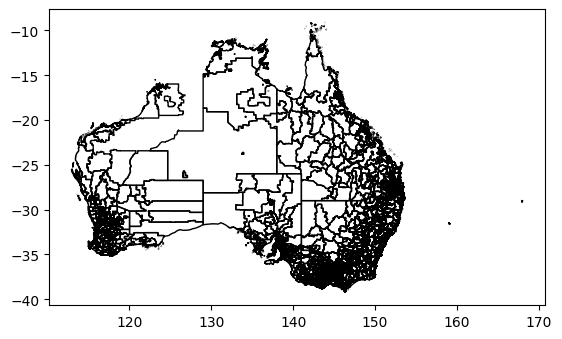

In [15]:
fig, ax = plt.subplots()
gdf_postcodes.plot(ax=ax, facecolor='none', edgecolor='black')


In [10]:
gdf.plot(ax=ax, color='red', markersize=2)
plt.show()